In [7]:
!pip install biopython scikit-learn pandas numpy matplotlib seaborn -q
print("All packages installed successfully.")

All packages installed successfully.


In [8]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from Bio import Entrez, SeqIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
ENTREZ_EMAIL  = "bilalzaib.microbio@gmail.com"
RANDOM_SEED   = 42
WINDOW_SIZE   = 50
MAX_KMERS     = 256
N_TREES       = 200

DOMAINS = {
    'TAD1':      (1,   40),
    'TAD2':      (41,  67),
    'Proline':   (68, 101),
    'DBD':      (102, 292),
    'Linker':   (293, 324),
    'Tetra':    (325, 356),
    'Regulatory':(357, 393),
}

HOTSPOT_CODONS = {175, 245, 248, 249, 273, 282}

print("Settings ready.")

Settings ready.


In [10]:
def get_domain(codon_number):
    for domain_name, (start, end) in DOMAINS.items():
        if start <= codon_number <= end:
            return domain_name
    return 'Other'

def get_first_codon(protein_change):
    first_entry = str(protein_change).split(',')[0].strip()
    match = re.search(r'(\d+)', first_entry)
    return int(match.group(1)) if match else None

def parse_spdi(spdi_string):
    try:
        parts = str(spdi_string).split(':')
        position  = int(parts[1])
        ref_base  = parts[2]
        alt_base  = parts[3]
        return position, ref_base, alt_base
    except:
        return None, None, None

def is_transition(ref_base, alt_base):
    if ref_base is None:
        return -1
    transitions = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
    return 1 if (ref_base, alt_base) in transitions else 0

def assign_label(clinical_significance):
    sig = str(clinical_significance).lower()
    is_pathogenic = 'pathogenic' in sig
    is_benign     = 'benign'     in sig
    is_conflict   = 'conflicting' in sig
    if is_pathogenic and not is_benign and not is_conflict:
        return 1
    if is_benign and not is_pathogenic and not is_conflict:
        return 0
    return -1

def extract_window(cds_sequence, codon_number, window=50):
    position_in_cds = (codon_number - 1) * 3
    start = max(0, position_in_cds - window)
    end   = min(len(cds_sequence), position_in_cds + window + 1)
    return cds_sequence[start:end]

TP53_START = 7661779
TP53_END   = 7687538

def genomic_to_relative(position):
    return (position - TP53_START) / (TP53_END - TP53_START)

print("Helper functions ready.")

Helper functions ready.


In [11]:
print("Downloading TP53 reference sequence from NCBI...")
Entrez.email = ENTREZ_EMAIL

handle = Entrez.efetch(
    db="nucleotide",
    id="NM_000546.6",
    rettype="gb",
    retmode="text"
)
genbank_record = SeqIO.read(handle, "genbank")
handle.close()

cds_start_position = 0
for feature in genbank_record.features:
    if feature.type == "CDS":
        cds_start_position = int(feature.location.start)
        break

ref_cds = str(genbank_record.seq)[cds_start_position:]

print(f"Download complete.")
print(f"CDS starts at position : {cds_start_position}")
print(f"CDS length             : {len(ref_cds)} bases")

Download complete.
CDS starts at position : 142
CDS length             : 2370 bases


In [12]:
print("Loading ClinVar data...")

df_raw = pd.read_csv(
    '/content/clinvar_result.txt',
    sep='\t',
    low_memory=False
)

print(f"File loaded: {len(df_raw)} variants")
print("\nClassification breakdown:")
print(df_raw['Germline classification'].value_counts())

Loading ClinVar data...
File loaded: 2739 variants

Classification breakdown:
Germline classification
Uncertain significance                                     732
Likely benign                                              698
Conflicting classifications of pathogenicity               505
Benign/Likely benign                                       260
Pathogenic                                                 174
Pathogenic/Likely pathogenic                               166
Benign                                                     102
Likely pathogenic                                           69
Pathogenic/Likely pathogenic/Pathogenic, low penetrance      1
not provided                                                 1
Name: count, dtype: int64


In [13]:
print("\nBuilding dataset...")

records      = []
excluded_vus = 0
excluded_pos = 0

for _, variant_row in df_raw.iterrows():
    label = assign_label(variant_row['Germline classification'])
    if label == -1:
        excluded_vus += 1
        continue

    position, ref_base, alt_base = parse_spdi(variant_row['Canonical SPDI'])
    if position is None:
        excluded_pos += 1
        continue

    codon = get_first_codon(variant_row['Protein change'])
    relative_pos = genomic_to_relative(position)
    domain  = get_domain(codon) if codon else 'Unknown'
    hotspot = int(codon in HOTSPOT_CODONS) if codon else 0

    if codon and 1 <= codon <= 393:
        dna_window = extract_window(ref_cds, codon, WINDOW_SIZE)
    else:
        estimated_codon = max(1, int(relative_pos * 393))
        dna_window = extract_window(ref_cds, estimated_codon, WINDOW_SIZE)

    if len(dna_window) < 30:
        excluded_pos += 1
        continue

    records.append({
        'sequence':    dna_window,
        'label':       label,
        'codon':       codon if codon else 0,
        'rel_pos':     relative_pos,
        'domain':      domain,
        'is_hotspot':  hotspot,
        'is_transition': is_transition(ref_base, alt_base),
        'ref_base':    ref_base,
        'alt_base':    alt_base,
        'clinsig':     str(variant_row['Germline classification']),
    })

df = pd.DataFrame(records)

n_pathogenic = (df['label'] == 1).sum()
n_benign     = (df['label'] == 0).sum()

print(f"\n===== DATASET SUMMARY =====")
print(f"Total variants used : {len(df)}")
print(f"Pathogenic / LP     : {n_pathogenic} ({n_pathogenic/len(df)*100:.1f}%)")
print(f"Benign / LB         : {n_benign}  ({n_benign/len(df)*100:.1f}%)")
print(f"Excluded (VUS)      : {excluded_vus}")
print(f"Excluded (no pos)   : {excluded_pos}")
print(f"\nDomain breakdown:")
print(df['domain'].value_counts())


Building dataset...

===== DATASET SUMMARY =====
Total variants used : 1470
Pathogenic / LP     : 410 (27.9%)
Benign / LB         : 1060  (72.1%)
Excluded (VUS)      : 1269
Excluded (no pos)   : 0

Domain breakdown:
domain
Unknown       993
DBD           388
TAD1           43
TAD2           18
Proline        17
Tetra           6
Linker          4
Regulatory      1
Name: count, dtype: int64


In [14]:
print("\nExtracting features...")

kmer_vectorizer = CountVectorizer(
    analyzer='char',
    ngram_range=(3, 4),
    max_features=MAX_KMERS
)
X_kmers = kmer_vectorizer.fit_transform(df['sequence']).toarray()

X_biological = df[['codon', 'rel_pos', 'is_hotspot', 'is_transition']].values

ref_encoded = pd.get_dummies(df['ref_base'], prefix='ref')
alt_encoded = pd.get_dummies(df['alt_base'], prefix='alt')
dom_encoded = pd.get_dummies(df['domain'], prefix='dom')

X = np.hstack([
    X_kmers,
    X_biological,
    ref_encoded.values,
    alt_encoded.values,
    dom_encoded.values
])

y = df['label'].values

feature_names = (
    list(kmer_vectorizer.get_feature_names_out()) +
    ['codon_pos', 'rel_pos', 'is_hotspot', 'is_transition'] +
    list(ref_encoded.columns) +
    list(alt_encoded.columns) +
    list(dom_encoded.columns)
)

print(f"Feature matrix size : {X.shape[0]} variants x {X.shape[1]} features")


Extracting features...
Feature matrix size : 1470 variants x 276 features


In [15]:
print("\nSplitting data and training model...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Training set : {len(X_train)} variants")
print(f"Test set     : {len(X_test)} variants")

model = RandomForestClassifier(
    n_estimators=N_TREES,
    min_samples_split=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced'
)
model.fit(X_train, y_train)
print("Model training complete.")

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores   = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='roc_auc')
print(f"\nCross-validation AUC scores: {[round(s,3) for s in cv_scores]}")
print(f"Mean: {cv_scores.mean():.4f}  |  SD: {cv_scores.std():.4f}")


Splitting data and training model...
Training set : 1176 variants
Test set     : 294 variants
Model training complete.

Cross-validation AUC scores: [np.float64(0.918), np.float64(0.912), np.float64(0.921), np.float64(0.891), np.float64(0.859)]
Mean: 0.9002  |  SD: 0.0232


In [16]:
y_predictions       = model.predict(X_test)
y_probabilities     = model.predict_proba(X_test)[:, 1]

auc_roc   = roc_auc_score(y_test, y_probabilities)
auprc     = average_precision_score(y_test, y_probabilities)
accuracy  = accuracy_score(y_test, y_predictions)
precision = precision_score(y_test, y_predictions)
recall    = recall_score(y_test, y_predictions)
f1        = f1_score(y_test, y_predictions)
spec      = recall_score(y_test, y_predictions, pos_label=0)

tn, fp, fn, tp = confusion_matrix(y_test, y_predictions).ravel()
npv = tn / (tn + fn)

print("\n===== EXACT NUMBERS FOR MANUSCRIPT =====")
print(f"Total variants   : {len(df)}")
print(f"Pathogenic/LP    : {n_pathogenic}")
print(f"Benign/LB        : {n_benign}")
print(f"Test set size    : {len(X_test)}")
print(f"AUC-ROC          : {auc_roc:.4f}")
print(f"AUPRC            : {auprc:.4f}")
print(f"Accuracy         : {accuracy:.4f}")
print(f"CV AUC mean      : {cv_scores.mean():.4f}")
print(f"CV AUC SD        : {cv_scores.std():.4f}")
print(f"Sensitivity      : {recall:.4f}")
print(f"Specificity      : {spec:.4f}")
print(f"PPV              : {precision:.4f}")
print(f"NPV              : {npv:.4f}")
print(f"F1               : {f1:.4f}")
print(f"N features       : {X.shape[1]}")

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_predictions,
      target_names=['Benign', 'Pathogenic']))


===== EXACT NUMBERS FOR MANUSCRIPT =====
Total variants   : 1470
Pathogenic/LP    : 410
Benign/LB        : 1060
Test set size    : 294
AUC-ROC          : 0.9183
AUPRC            : 0.8359
Accuracy         : 0.8776
CV AUC mean      : 0.9002
CV AUC SD        : 0.0232
Sensitivity      : 0.6951
Specificity      : 0.9481
PPV              : 0.8382
NPV              : 0.8894
F1               : 0.7600
N features       : 276

--- Full Classification Report ---
              precision    recall  f1-score   support

      Benign       0.89      0.95      0.92       212
  Pathogenic       0.84      0.70      0.76        82

    accuracy                           0.88       294
   macro avg       0.86      0.82      0.84       294
weighted avg       0.88      0.88      0.87       294



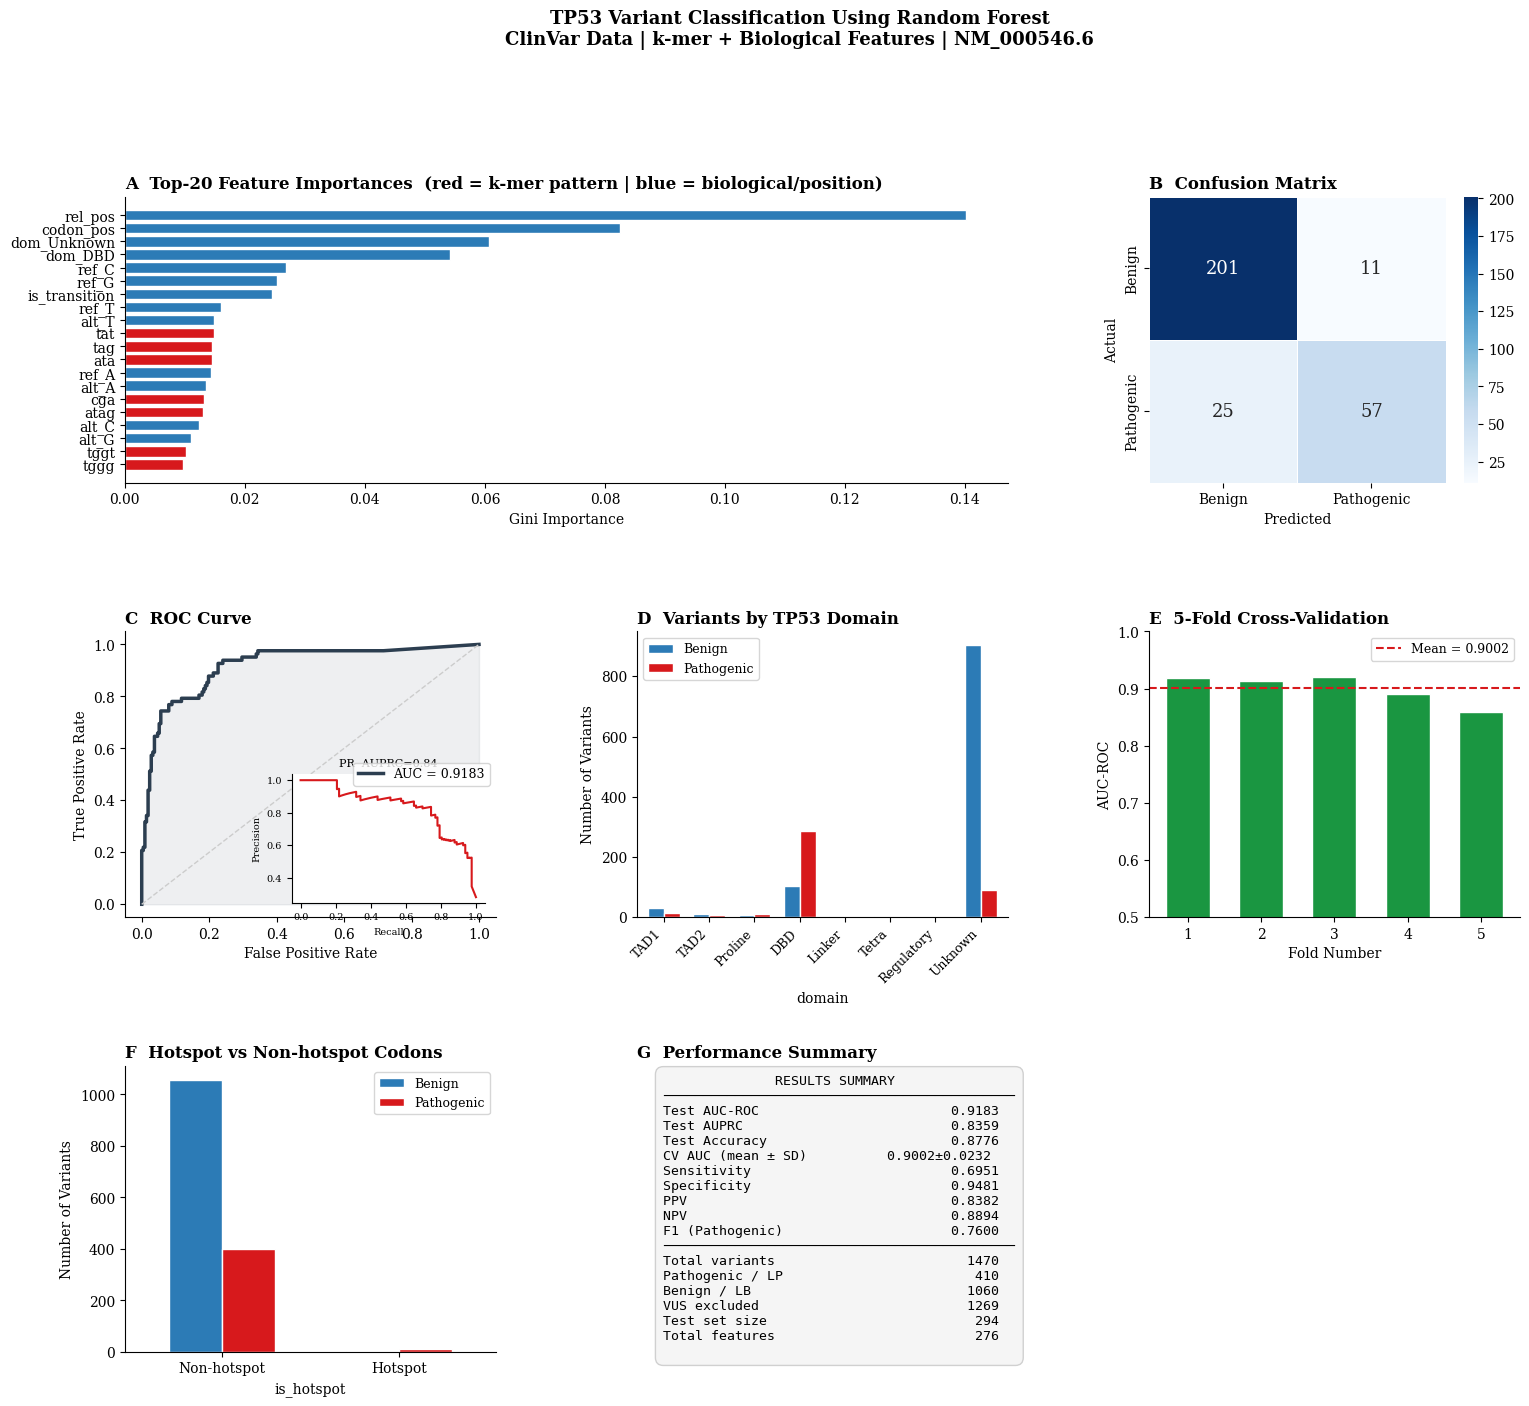

Figure 1 saved as Figure1_TP53_RF.png


In [17]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BLUE  = '#2c7bb6'
RED   = '#d7191c'
GREEN = '#1a9641'
GREY  = '#cccccc'

fig = plt.figure(figsize=(18, 15))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# Panel A: Top 20 most important features
ax_a = fig.add_subplot(gs[0, :2])
importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': model.feature_importances_
}).nlargest(20, 'importance')

biological_features = {'codon_pos', 'rel_pos', 'is_hotspot', 'is_transition'}
bar_colors = [
    BLUE if (f.startswith('dom_') or f.startswith('ref_') or
             f.startswith('alt_') or f in biological_features)
    else RED
    for f in importance_df['feature']
]
ax_a.barh(importance_df['feature'], importance_df['importance'],
          color=bar_colors, edgecolor='white')
ax_a.invert_yaxis()
ax_a.set_xlabel('Gini Importance')
ax_a.set_title('A  Top-20 Feature Importances  (red = k-mer pattern | blue = biological/position)',
               loc='left', fontweight='bold')

# Panel B: Confusion matrix
ax_b = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_b,
            xticklabels=['Benign', 'Pathogenic'],
            yticklabels=['Benign', 'Pathogenic'],
            annot_kws={'size': 13}, linewidths=0.5)
ax_b.set_xlabel('Predicted')
ax_b.set_ylabel('Actual')
ax_b.set_title('B  Confusion Matrix', loc='left', fontweight='bold')

# Panel C: ROC curve
ax_c = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_probabilities)
ax_c.plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'AUC = {auc_roc:.4f}')
ax_c.fill_between(fpr, tpr, alpha=0.08, color='#2c3e50')
ax_c.plot([0, 1], [0, 1], '--', color=GREY, lw=1)
ax_c.set_xlabel('False Positive Rate')
ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C  ROC Curve', loc='left', fontweight='bold')
ax_c.legend(fontsize=9)

# PR inset
ax_ins = ax_c.inset_axes([0.45, 0.05, 0.52, 0.45])
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_probabilities)
ax_ins.plot(pr_recall, pr_precision, color=RED, lw=1.5)
ax_ins.set_title(f'PR  AUPRC={auprc:.2f}', fontsize=8)
ax_ins.set_xlabel('Recall', fontsize=7)
ax_ins.set_ylabel('Precision', fontsize=7)
ax_ins.tick_params(labelsize=7)

# Panel D: Variants by domain
ax_d = fig.add_subplot(gs[1, 1])
domain_order = [d for d in list(DOMAINS.keys()) + ['Other', 'Unknown']
                if d in df['domain'].unique()]
domain_table = (
    df.groupby(['domain', 'label']).size()
      .unstack(fill_value=0)
      .rename(columns={0: 'Benign', 1: 'Pathogenic'})
      .reindex(domain_order)
)
domain_table.plot(kind='bar', ax=ax_d, color=[BLUE, RED],
                  edgecolor='white', width=0.7)
ax_d.set_xticklabels(ax_d.get_xticklabels(),
                      rotation=45, ha='right', fontsize=9)
ax_d.set_ylabel('Number of Variants')
ax_d.set_title('D  Variants by TP53 Domain', loc='left', fontweight='bold')
ax_d.legend(fontsize=9)

# Panel E: Cross-validation
ax_e = fig.add_subplot(gs[1, 2])
ax_e.bar(range(1, 6), cv_scores, color=GREEN, edgecolor='white', width=0.6)
ax_e.axhline(cv_scores.mean(), color=RED, linestyle='--', lw=1.5,
             label=f'Mean = {cv_scores.mean():.4f}')
ax_e.set_xlabel('Fold Number')
ax_e.set_ylabel('AUC-ROC')
ax_e.set_ylim(0.5, 1.0)
ax_e.set_title('E  5-Fold Cross-Validation', loc='left', fontweight='bold')
ax_e.legend(fontsize=9)

# Panel F: Hotspot vs non-hotspot
ax_f = fig.add_subplot(gs[2, 0])
hotspot_table = (
    df.groupby(['is_hotspot', 'label']).size()
      .unstack(fill_value=0)
      .rename(columns={0: 'Benign', 1: 'Pathogenic'})
      .rename(index={0: 'Non-hotspot', 1: 'Hotspot'})
)
hotspot_table.plot(kind='bar', ax=ax_f, color=[BLUE, RED],
                   edgecolor='white', width=0.6)
ax_f.set_xticklabels(ax_f.get_xticklabels(), rotation=0)
ax_f.set_ylabel('Number of Variants')
ax_f.set_title('F  Hotspot vs Non-hotspot Codons', loc='left', fontweight='bold')
ax_f.legend(fontsize=9)

# Panel G: Summary table
ax_g = fig.add_subplot(gs[2, 1:])
ax_g.axis('off')
summary_text = (
    f"{'RESULTS SUMMARY':^44}\n{'─'*44}\n"
    f"{'Test AUC-ROC':<28}{auc_roc:>14.4f}\n"
    f"{'Test AUPRC':<28}{auprc:>14.4f}\n"
    f"{'Test Accuracy':<28}{accuracy:>14.4f}\n"
    f"{'CV AUC (mean ± SD)':<28}{cv_scores.mean():.4f}±{cv_scores.std():.4f}\n"
    f"{'Sensitivity':<28}{recall:>14.4f}\n"
    f"{'Specificity':<28}{spec:>14.4f}\n"
    f"{'PPV':<28}{precision:>14.4f}\n"
    f"{'NPV':<28}{npv:>14.4f}\n"
    f"{'F1 (Pathogenic)':<28}{f1:>14.4f}\n"
    f"{'─'*44}\n"
    f"{'Total variants':<28}{len(df):>14}\n"
    f"{'Pathogenic / LP':<28}{n_pathogenic:>14}\n"
    f"{'Benign / LB':<28}{n_benign:>14}\n"
    f"{'VUS excluded':<28}{excluded_vus:>14}\n"
    f"{'Test set size':<28}{len(X_test):>14}\n"
    f"{'Total features':<28}{X.shape[1]:>14}\n"
)
ax_g.text(0.03, 0.97, summary_text,
          transform=ax_g.transAxes,
          fontsize=9.5, verticalalignment='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#f4f4f4',
                    edgecolor='#cccccc', alpha=0.9))
ax_g.set_title('G  Performance Summary', loc='left', fontweight='bold')

plt.suptitle(
    'TP53 Variant Classification Using Random Forest\n'
    'ClinVar Data | k-mer + Biological Features | NM_000546.6',
    fontsize=13, fontweight='bold', y=1.005
)

plt.savefig('Figure1_TP53_RF.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved as Figure1_TP53_RF.png")

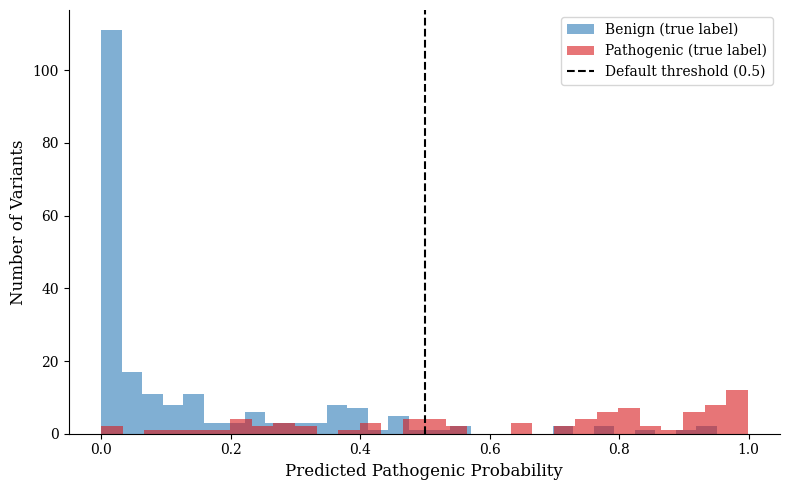

Figure 2 saved as Figure2_probability_dist.png


In [25]:
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.family': 'serif', 'axes.spines.top': False,
                     'axes.spines.right': False})

plt.hist(y_probabilities[y_test == 0], bins=30, alpha=0.6,
         color='#2c7bb6', label='Benign (true label)')
plt.hist(y_probabilities[y_test == 1], bins=30, alpha=0.6,
         color='#d7191c', label='Pathogenic (true label)')
plt.axvline(0.5, color='black', linestyle='--',
            lw=1.5, label='Default threshold (0.5)')

plt.xlabel('Predicted Pathogenic Probability', fontsize=12)
plt.ylabel('Number of Variants', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Figure2_probability_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 saved as Figure2_probability_dist.png")

In [19]:
print("Preparing SIFT benchmark variant data for uploading...")

protein_changes = df_raw['Protein change'].dropna().unique()
missense = []
for x in protein_changes:
    s = str(x).strip()
    if re.search(r'^[A-Z]\d+[A-Z]$', s):
        missense.append(s)

print(f"Found {len(missense)} clean missense variants ready for SIFT.")

with open('sift_tp53_substitutions.txt', 'w') as f:
    for sub in missense:
        f.write(sub + '\n')

print("\nFile 'sift_tp53_substitutions.txt' created successfully!")
print("Next steps:")
print("1. Go to https://sift.bii.a-star.edu.sg/")
print("2. Upload TP53 protein sequence (UniProt P04637 FASTA)")
print("3. Upload or paste the substitutions from the downloaded file")
print("4. Run SIFT → download results")

from google.colab import files
files.download('sift_tp53_substitutions.txt')
print("SIFT input file downloaded automatically!")

Preparing SIFT benchmark variant data for uploading...
Found 93 clean missense variants ready for SIFT.

File 'sift_tp53_substitutions.txt' created successfully!
Next steps:
1. Go to https://sift.bii.a-star.edu.sg/
2. Upload TP53 protein sequence (UniProt P04637 FASTA)
3. Upload or paste the substitutions from the downloaded file
4. Run SIFT → download results


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SIFT input file downloaded automatically!


===== TABLE 5: DOMAIN STRATIFIED PERFORMANCE =====
Region                        n     AUC    Sens    Spec
Overall                     294  0.9183  0.6951  0.9481
DBD (codons 102-292)         69  0.7667  0.9074  0.5333
Non-DBD                     225  0.8508  0.2857  0.9797


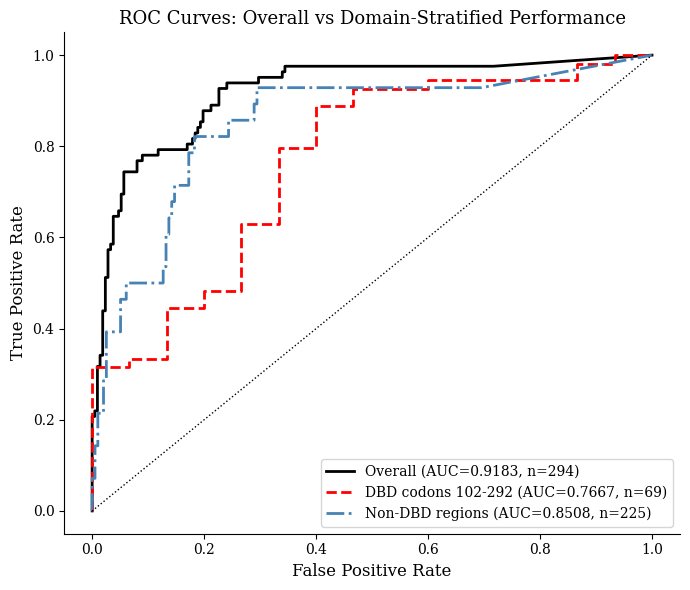

Figure 3 saved!


In [20]:
from sklearn.metrics import roc_curve

# Rebuild test dataframe
_, X_test_df, _, _ = train_test_split(
    df, df['label'], test_size=0.2,
    random_state=RANDOM_SEED, stratify=df['label']
)

codon_positions = X_test_df['codon'].values
dbd_mask = (codon_positions >= 102) & (codon_positions <= 292)
non_dbd_mask = ~dbd_mask

y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
def get_metrics(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()
    return (len(y_true),
            round(roc_auc_score(y_true, y_proba), 4),
            round(tp/(tp+fn), 4),
            round(tn/(tn+fp), 4))

n1,auc1,sen1,spe1 = get_metrics(y_test, y_pred_proba)
n2,auc2,sen2,spe2 = get_metrics(y_test[dbd_mask], y_pred_proba[dbd_mask])
n3,auc3,sen3,spe3 = get_metrics(y_test[non_dbd_mask], y_pred_proba[non_dbd_mask])

print("===== TABLE 5: DOMAIN STRATIFIED PERFORMANCE =====")
print(f"{'Region':<25} {'n':>5} {'AUC':>7} {'Sens':>7} {'Spec':>7}")
print(f"{'Overall':<25} {n1:>5} {auc1:>7} {sen1:>7} {spe1:>7}")
print(f"{'DBD (codons 102-292)':<25} {n2:>5} {auc2:>7} {sen2:>7} {spe2:>7}")
print(f"{'Non-DBD':<25} {n3:>5} {auc3:>7} {sen3:>7} {spe3:>7}")

# Figure 3
fpr_all,tpr_all,_ = roc_curve(y_test, y_pred_proba)
fpr_dbd,tpr_dbd,_ = roc_curve(y_test[dbd_mask], y_pred_proba[dbd_mask])
fpr_non,tpr_non,_ = roc_curve(y_test[non_dbd_mask], y_pred_proba[non_dbd_mask])

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(fpr_all, tpr_all, color='black', lw=2,
        label=f'Overall (AUC={auc1}, n={n1})')
ax.plot(fpr_dbd, tpr_dbd, color='red', lw=2, linestyle='--',
        label=f'DBD codons 102-292 (AUC={auc2}, n={n2})')
ax.plot(fpr_non, tpr_non, color='steelblue', lw=2, linestyle='-.',
        label=f'Non-DBD regions (AUC={auc3}, n={n3})')
ax.plot([0,1],[0,1],'k:',lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Overall vs Domain-Stratified Performance',
             fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('Figure3_DBD_stratified.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved!")

In [21]:
import os

# Find CADD file
cadd_path = None
for f in os.listdir('/'):
    if 'GRCh38' in f:
        cadd_path = '/' + f
        print(f"CADD found: {cadd_path}")
        break

if cadd_path is None:
    print("CADD file not found — please upload it")
else:
    cadd = pd.read_csv(cadd_path, sep='\t', comment='#',
                       header=None,
                       names=['Chrom','Pos','Ref','Alt','RawScore','PHRED'])
    cadd['Pos'] = pd.to_numeric(cadd['Pos'])
    cadd['PHRED'] = pd.to_numeric(cadd['PHRED'])

    # Parse coordinates from df_raw
    spdi = df_raw['Canonical SPDI'].str.split(':', expand=True)
    df_raw['pos'] = pd.to_numeric(spdi[1], errors='coerce')
    df_raw['ref_spdi'] = spdi[2]
    df_raw['alt_spdi'] = spdi[3]

    labeled = df_raw[df_raw['Germline classification'].isin([
        'Pathogenic','Likely pathogenic',
        'Benign','Likely benign'])].copy()
    labeled['label'] = labeled['Germline classification'].isin(
        ['Pathogenic','Likely pathogenic']).astype(int)
    labeled['pos_shifted'] = labeled['pos'] + 1

    # Full dataset merge
    merged = labeled.merge(cadd,
        left_on=['pos_shifted','ref_spdi','alt_spdi'],
        right_on=['Pos','Ref','Alt'], how='inner')

    print(f"Matched: {len(merged)}")
    print(f"Pathogenic: {merged['label'].sum()}")
    print(f"Benign: {(merged['label']==0).sum()}")

    if merged['label'].sum() >= 5:
        cadd_auc = roc_auc_score(merged['label'], merged['PHRED'])
        tn,fp,fn,tp = confusion_matrix(merged['label'],
                       (merged['PHRED']>=20).astype(int)).ravel()
        print(f"\n===== CADD BENCHMARK =====")
        print(f"CADD AUC-ROC:     {cadd_auc:.4f}")
        print(f"CADD Sensitivity: {tp/(tp+fn):.4f}")
        print(f"CADD Specificity: {tn/(tn+fp):.4f}")
        print(f"Matched n:        {len(merged)}")

CADD file not found — please upload it


In [22]:
# ── CELL 16: CADD Benchmark ──────────────────────────────────────
import os

# Find CADD file
cadd_path = None
for f in os.listdir('/'):
    if 'GRCh38' in f:
        cadd_path = '/' + f
        print(f"CADD found: {cadd_path}")
        break

if cadd_path is None:
    print("CADD file not found — please upload it")
else:
    cadd = pd.read_csv(cadd_path, sep='\t', comment='#',
                       header=None,
                       names=['Chrom','Pos','Ref','Alt','RawScore','PHRED'])
    cadd['Pos'] = pd.to_numeric(cadd['Pos'])
    cadd['PHRED'] = pd.to_numeric(cadd['PHRED'])

    # Parse coordinates from df_raw
    spdi = df_raw['Canonical SPDI'].str.split(':', expand=True)
    df_raw['pos'] = pd.to_numeric(spdi[1], errors='coerce')
    df_raw['ref_spdi'] = spdi[2]
    df_raw['alt_spdi'] = spdi[3]

    labeled = df_raw[df_raw['Germline classification'].isin([
        'Pathogenic','Likely pathogenic',
        'Benign','Likely benign'])].copy()
    labeled['label'] = labeled['Germline classification'].isin(
        ['Pathogenic','Likely pathogenic']).astype(int)
    labeled['pos_shifted'] = labeled['pos'] + 1

    # Full dataset merge
    merged = labeled.merge(cadd,
        left_on=['pos_shifted','ref_spdi','alt_spdi'],
        right_on=['Pos','Ref','Alt'], how='inner')

    print(f"Matched: {len(merged)}")
    print(f"Pathogenic: {merged['label'].sum()}")
    print(f"Benign: {(merged['label']==0).sum()}")

    if merged['label'].sum() >= 5:
        cadd_auc = roc_auc_score(merged['label'], merged['PHRED'])
        tn,fp,fn,tp = confusion_matrix(merged['label'],
                       (merged['PHRED']>=20).astype(int)).ravel()
        print(f"\n===== CADD BENCHMARK =====")
        print(f"CADD AUC-ROC:     {cadd_auc:.4f}")
        print(f"CADD Sensitivity: {tp/(tp+fn):.4f}")
        print(f"CADD Specificity: {tn/(tn+fp):.4f}")
        print(f"Matched n:        {len(merged)}")

CADD file not found — please upload it


In [23]:
import os

files = os.listdir('/content')

print(files)

['.config', 'Figure2_probability_dist.png', 'Figure3_DBD_stratified.png', 'clinvar_result.txt', 'Figure1_TP53_RF.png', 'sift_tp53_substitutions.txt', 'drive', 'sample_data']


In [24]:
import pandas as pd
from sklearn.metrics import roc_auc_score, confusion_matrix

# Correct CADD file path
cadd_path = '/content/GRCh38-v1.6_34cd0b53c8943e920eb2333514b3ef40.tsv.gz (1).tsv'

# Read CADD
cadd = pd.read_csv(
    cadd_path,
    sep='\t',
    comment='#',
    header=None,
    names=['Chrom','Pos','Ref','Alt','RawScore','PHRED']
)

print(cadd.head())

# Convert numeric columns
cadd['Pos'] = pd.to_numeric(cadd['Pos'], errors='coerce')
cadd['PHRED'] = pd.to_numeric(cadd['PHRED'], errors='coerce')

print("\nLoaded rows:", len(cadd))



FileNotFoundError: [Errno 2] No such file or directory: '/content/GRCh38-v1.6_34cd0b53c8943e920eb2333514b3ef40.tsv.gz (1).tsv'

In [ ]:
# Parse SPDI coordinates
spdi = df_raw['Canonical SPDI'].str.split(':', expand=True)

df_raw['pos'] = pd.to_numeric(spdi[1], errors='coerce')
df_raw['ref_spdi'] = spdi[2]
df_raw['alt_spdi'] = spdi[3]

# Keep only labeled variants
labeled = df_raw[df_raw['Germline classification'].isin([
    'Pathogenic',
    'Likely pathogenic',
    'Benign',
    'Likely benign'
])].copy()

# Binary labels
labeled['label'] = labeled['Germline classification'].isin([
    'Pathogenic',
    'Likely pathogenic'
]).astype(int)

# SPDI is 0-based, CADD is 1-based
labeled['pos_shifted'] = labeled['pos'] + 1

print(labeled[['Canonical SPDI',
               'pos_shifted',
               'ref_spdi',
               'alt_spdi',
               'label']].head())

In [ ]:
merged = labeled.merge(
    cadd,
    left_on=['pos_shifted', 'ref_spdi', 'alt_spdi'],
    right_on=['Pos', 'Ref', 'Alt'],
    how='inner'
)

print("Matched variants:", len(merged))

print("\nColumns:")
print(merged.columns.tolist())

print("\nPreview:")
print(
    merged[
        ['Canonical SPDI',
         'Germline classification',
         'PHRED',
         'RawScore']
    ].head()
)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# ROC-AUC
cadd_auc = roc_auc_score(
    merged['label'],
    merged['PHRED']
)

# Standard CADD threshold
pred = (merged['PHRED'] >= 20).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    merged['label'],
    pred
).ravel()

# Metrics
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

accuracy = accuracy_score(merged['label'], pred)
precision = precision_score(merged['label'], pred)
f1 = f1_score(merged['label'], pred)
mcc = matthews_corrcoef(merged['label'], pred)

print("===== CADD BENCHMARK =====\n")

print(f"AUC-ROC:     {cadd_auc:.4f}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"MCC:         {mcc:.4f}")

print("\n===== COUNTS =====")
print(f"TP: {tp}")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")

print(f"\nMatched variants: {len(merged)}")